## Module 4: *(Template)*

## Team Members:
Luke Friscia and Hayden Rue

## Project Title:
MMP9 as a Predictor for Metastatic Progression, Tumor Stage, and Survival in Melanoma Patients

## Project Goal:
This project seeks to determine if MMP9 expression is a predictor of metastatic progression, tumor stage, and survival outcomes in Melanoma patients.

## Dataset Background

This study uses data collected from The Cancer Genome Atlas (TCGA), a widespread cancer genomics initiative that characterizes many features across multiple types of cancer. Specifically, we have used the RNA-seq dataset reprocessed by Rahman et al., which standardizes gene expression measurements across tumors.

From the full TCGA dataset (~9,264 tumor samples across 24 cancer types), a subset of ~1,802 tumors was selected, with approximately 50–100 samples per cancer type.

For this project analysis, the dataset was further filtered to include only Skin Cutaneous Melanoma (SKCM) patients. Lymph node status, survival outcomes, and age at diagnosis are also relevant columns in the dataset that will be used for this project.

Data was obtained from tumor samples via surgical biopsy. Gene expression was measured using RNA sequencing. Clinical data, including tumor stage, lymph node involvement, and survival outcomes, were derived from patient medical records and classified using the TNM staging system. Survival time was recorded in days from diagnosis to last follow-up or death.

## Data Analysis: 

### Methods
3. Your analysis so far is thoughtfully explained, and you have a clear plan for a machine learning technique to answer your question. You explain the supervised learning model you will use and why it's a good first choice to answer your question. 




The machine learning technique I am using is: *fill in and describe*

*What is this method optimizing? How does the model decide it is "good enough"?*

**

### Analysis

MMP9 expression was analyzed using multiple clinical association plots that highlight different dependent variables.

First, MMP9 expression was plotted vs metastasis status in a boxplot across the different status levels collected from TCGA.

Data shape: (15716, 1802)
Metadata shape: (1802, 29)
Matched patients: 1795
Matched SKCM samples: 80
Gene data shape: (151, 80)


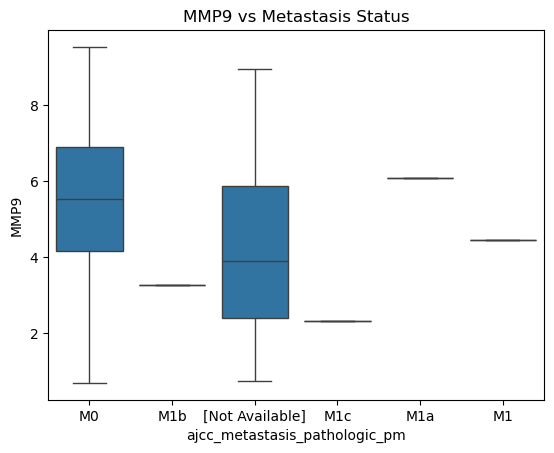

In [3]:
# Importing the libraries we need for this analysis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# Load in the gene expression data and the metadata
# index_col=0 means the first column is used as row the labels
data = pd.read_csv(
    '/Users/haydenrue/Desktop/Comp BME/Module-4-Cancer/data/TRAINING_SET_GSE62944_subsample_log2TPM.csv',
    index_col=0
)

metadata_df = pd.read_csv(
    '/Users/haydenrue/Desktop/Comp BME/Module-4-Cancer/data/TRAINING_SET_GSE62944_metadata.csv',
    index_col=0
)

# Print shapes to confirm everything loaded correctly
print("Data shape:", data.shape)
print("Metadata shape:", metadata_df.shape)


# The sample IDs in the gene data and metadata don’t perfectly match,
# so we shorten them to the first 12 characters
data_short = data.columns.str[:12]
meta_short = metadata_df.index.str[:12]

# map shortened IDs back to full IDs
data_map = dict(zip(data_short, data.columns))
meta_map = dict(zip(meta_short, metadata_df.index))

# Find which patient IDs exist in both datasets
common_ids = set(data_short).intersection(set(meta_short))
print("Matched patients:", len(common_ids))

# Use only the matched samples
data_cols_final = [data_map[i] for i in common_ids]
meta_idx_final = [meta_map[i] for i in common_ids]

data = data[data_cols_final]
metadata_df = metadata_df.loc[meta_idx_final]


# Filter down to only SKCM (melanoma) samples
cancer_type = 'SKCM'

cancer_samples = metadata_df[metadata_df['cancer_type'] == cancer_type].index
common_samples = data.columns.intersection(cancer_samples)

print("Matched SKCM samples:", len(common_samples))

SKCM_data = data[common_samples]
SKCM_metadata = metadata_df.loc[common_samples]


# Select the most variable genes since they carry the most information
# Also make sure MMP9 is included even if it’s not the most variable
gene_variance = SKCM_data.var(axis=1)
top_genes = gene_variance.sort_values(ascending=False).head(150).index

genes = list(set(top_genes).union({'MMP9'}))
SKCM_gene_data = SKCM_data.loc[genes]

print("Gene data shape:", SKCM_gene_data.shape)


# Combine gene expression data with clinical metadata into one dataframe
# Transpose is needed so samples become rows
SKCM_merged = SKCM_gene_data.T.merge(
    SKCM_metadata, left_index=True, right_index=True
)


# Remove rows with missing values for key variables we need
SKCM_merged = SKCM_merged.dropna(subset=[
    'MMP9',
    'ajcc_nodes_pathologic_pn',
    'ajcc_metastasis_pathologic_pm',
    'ajcc_pathologic_tumor_stage',
    'OS',
    'OS.time'
])


# Clinical association plots

# Compare MMP9 expression across metastasis categories
sns.boxplot(data=SKCM_merged,
            x='ajcc_metastasis_pathologic_pm',
            y='MMP9')
plt.title("MMP9 vs Metastasis Status")
plt.show()

Next, MMP9 expression was plotted against the different tumor stages as collected from TCGA.

Data shape: (15716, 1802)
Metadata shape: (1802, 29)
Matched patients: 1795
Matched SKCM samples: 80
Gene data shape: (151, 80)


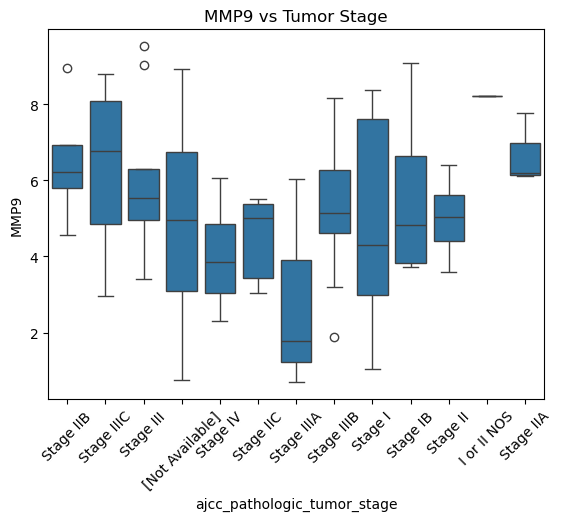

In [4]:
# Importing the libraries we need for this analysis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# Load in the gene expression data and the metadata
# index_col=0 means the first column is used as row the labels
data = pd.read_csv(
    '/Users/haydenrue/Desktop/Comp BME/Module-4-Cancer/data/TRAINING_SET_GSE62944_subsample_log2TPM.csv',
    index_col=0
)

metadata_df = pd.read_csv(
    '/Users/haydenrue/Desktop/Comp BME/Module-4-Cancer/data/TRAINING_SET_GSE62944_metadata.csv',
    index_col=0
)

# Print shapes to confirm everything loaded correctly
print("Data shape:", data.shape)
print("Metadata shape:", metadata_df.shape)


# The sample IDs in the gene data and metadata don’t perfectly match,
# so we shorten them to the first 12 characters
data_short = data.columns.str[:12]
meta_short = metadata_df.index.str[:12]

# map shortened IDs back to full IDs
data_map = dict(zip(data_short, data.columns))
meta_map = dict(zip(meta_short, metadata_df.index))

# Find which patient IDs exist in both datasets
common_ids = set(data_short).intersection(set(meta_short))
print("Matched patients:", len(common_ids))

# Use only the matched samples
data_cols_final = [data_map[i] for i in common_ids]
meta_idx_final = [meta_map[i] for i in common_ids]

data = data[data_cols_final]
metadata_df = metadata_df.loc[meta_idx_final]


# Filter down to only SKCM (melanoma) samples
cancer_type = 'SKCM'

cancer_samples = metadata_df[metadata_df['cancer_type'] == cancer_type].index
common_samples = data.columns.intersection(cancer_samples)

print("Matched SKCM samples:", len(common_samples))

SKCM_data = data[common_samples]
SKCM_metadata = metadata_df.loc[common_samples]


# Select the most variable genes since they carry the most information
# Also make sure MMP9 is included even if it’s not the most variable
gene_variance = SKCM_data.var(axis=1)
top_genes = gene_variance.sort_values(ascending=False).head(150).index

genes = list(set(top_genes).union({'MMP9'}))
SKCM_gene_data = SKCM_data.loc[genes]

print("Gene data shape:", SKCM_gene_data.shape)


# Combine gene expression data with clinical metadata into one dataframe
# Transpose is needed so samples become rows
SKCM_merged = SKCM_gene_data.T.merge(
    SKCM_metadata, left_index=True, right_index=True
)


# Remove rows with missing values for key variables we need
SKCM_merged = SKCM_merged.dropna(subset=[
    'MMP9',
    'ajcc_nodes_pathologic_pn',
    'ajcc_metastasis_pathologic_pm',
    'ajcc_pathologic_tumor_stage',
    'OS',
    'OS.time'
])


# Clinical association plots

# Compare MMP9 across tumor stages
sns.boxplot(data=SKCM_merged,
            x='ajcc_pathologic_tumor_stage',
            y='MMP9')
plt.title("MMP9 vs Tumor Stage")
plt.xticks(rotation=45)
plt.show()

MMP9 expression was then plotted against survival status (alive vs deceased)

Data shape: (15716, 1802)
Metadata shape: (1802, 29)
Matched patients: 1795
Matched SKCM samples: 80
Gene data shape: (151, 80)


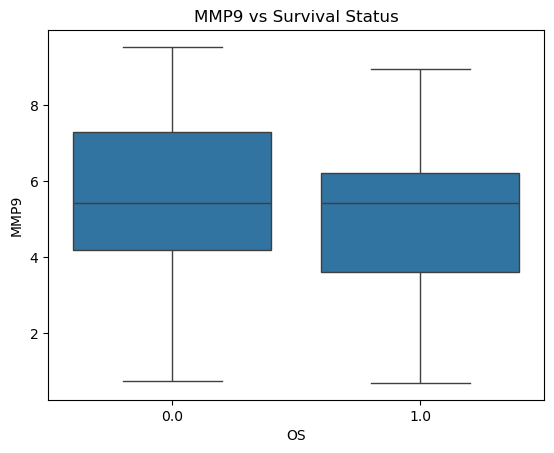

In [5]:
# Importing the libraries we need for this analysis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# Load in the gene expression data and the metadata
# index_col=0 means the first column is used as row the labels
data = pd.read_csv(
    '/Users/haydenrue/Desktop/Comp BME/Module-4-Cancer/data/TRAINING_SET_GSE62944_subsample_log2TPM.csv',
    index_col=0
)

metadata_df = pd.read_csv(
    '/Users/haydenrue/Desktop/Comp BME/Module-4-Cancer/data/TRAINING_SET_GSE62944_metadata.csv',
    index_col=0
)

# Print shapes to confirm everything loaded correctly
print("Data shape:", data.shape)
print("Metadata shape:", metadata_df.shape)


# The sample IDs in the gene data and metadata don’t perfectly match,
# so we shorten them to the first 12 characters
data_short = data.columns.str[:12]
meta_short = metadata_df.index.str[:12]

# map shortened IDs back to full IDs
data_map = dict(zip(data_short, data.columns))
meta_map = dict(zip(meta_short, metadata_df.index))

# Find which patient IDs exist in both datasets
common_ids = set(data_short).intersection(set(meta_short))
print("Matched patients:", len(common_ids))

# Use only the matched samples
data_cols_final = [data_map[i] for i in common_ids]
meta_idx_final = [meta_map[i] for i in common_ids]

data = data[data_cols_final]
metadata_df = metadata_df.loc[meta_idx_final]


# Filter down to only SKCM (melanoma) samples
cancer_type = 'SKCM'

cancer_samples = metadata_df[metadata_df['cancer_type'] == cancer_type].index
common_samples = data.columns.intersection(cancer_samples)

print("Matched SKCM samples:", len(common_samples))

SKCM_data = data[common_samples]
SKCM_metadata = metadata_df.loc[common_samples]


# Select the most variable genes since they carry the most information
# Also make sure MMP9 is included even if it’s not the most variable
gene_variance = SKCM_data.var(axis=1)
top_genes = gene_variance.sort_values(ascending=False).head(150).index

genes = list(set(top_genes).union({'MMP9'}))
SKCM_gene_data = SKCM_data.loc[genes]

print("Gene data shape:", SKCM_gene_data.shape)


# Combine gene expression data with clinical metadata into one dataframe
# Transpose is needed so samples become rows
SKCM_merged = SKCM_gene_data.T.merge(
    SKCM_metadata, left_index=True, right_index=True
)


# Remove rows with missing values for key variables we need
SKCM_merged = SKCM_merged.dropna(subset=[
    'MMP9',
    'ajcc_nodes_pathologic_pn',
    'ajcc_metastasis_pathologic_pm',
    'ajcc_pathologic_tumor_stage',
    'OS',
    'OS.time'
])


# Clinical association plots

# Compare MMP9 between patients who are alive vs deceased
sns.boxplot(data=SKCM_merged,
            x='OS',
            y='MMP9')
plt.title("MMP9 vs Survival Status")
plt.show()

The final clinical associaton plot plotted MMP9 expression vs patient survival time from diagnosis.

Data shape: (15716, 1802)
Metadata shape: (1802, 29)
Matched patients: 1795
Matched SKCM samples: 80
Gene data shape: (151, 80)


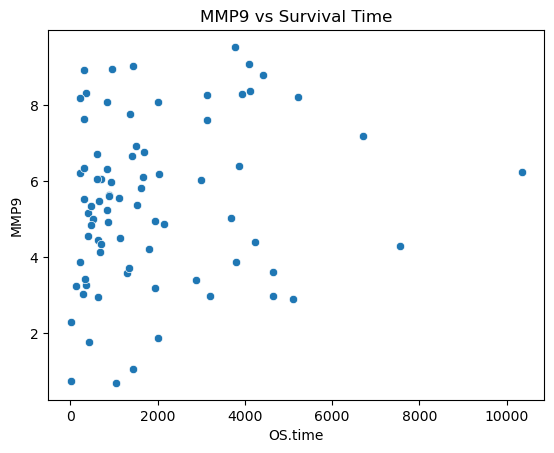

In [6]:
# Importing the libraries we need for this analysis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# Load in the gene expression data and the metadata
# index_col=0 means the first column is used as row the labels
data = pd.read_csv(
    '/Users/haydenrue/Desktop/Comp BME/Module-4-Cancer/data/TRAINING_SET_GSE62944_subsample_log2TPM.csv',
    index_col=0
)

metadata_df = pd.read_csv(
    '/Users/haydenrue/Desktop/Comp BME/Module-4-Cancer/data/TRAINING_SET_GSE62944_metadata.csv',
    index_col=0
)

# Print shapes to confirm everything loaded correctly
print("Data shape:", data.shape)
print("Metadata shape:", metadata_df.shape)


# The sample IDs in the gene data and metadata don’t perfectly match,
# so we shorten them to the first 12 characters
data_short = data.columns.str[:12]
meta_short = metadata_df.index.str[:12]

# map shortened IDs back to full IDs
data_map = dict(zip(data_short, data.columns))
meta_map = dict(zip(meta_short, metadata_df.index))

# Find which patient IDs exist in both datasets
common_ids = set(data_short).intersection(set(meta_short))
print("Matched patients:", len(common_ids))

# Use only the matched samples
data_cols_final = [data_map[i] for i in common_ids]
meta_idx_final = [meta_map[i] for i in common_ids]

data = data[data_cols_final]
metadata_df = metadata_df.loc[meta_idx_final]


# Filter down to only SKCM (melanoma) samples
cancer_type = 'SKCM'

cancer_samples = metadata_df[metadata_df['cancer_type'] == cancer_type].index
common_samples = data.columns.intersection(cancer_samples)

print("Matched SKCM samples:", len(common_samples))

SKCM_data = data[common_samples]
SKCM_metadata = metadata_df.loc[common_samples]


# Select the most variable genes since they carry the most information
# Also make sure MMP9 is included even if it’s not the most variable
gene_variance = SKCM_data.var(axis=1)
top_genes = gene_variance.sort_values(ascending=False).head(150).index

genes = list(set(top_genes).union({'MMP9'}))
SKCM_gene_data = SKCM_data.loc[genes]

print("Gene data shape:", SKCM_gene_data.shape)


# Combine gene expression data with clinical metadata into one dataframe
# Transpose is needed so samples become rows
SKCM_merged = SKCM_gene_data.T.merge(
    SKCM_metadata, left_index=True, right_index=True
)


# Remove rows with missing values for key variables we need
SKCM_merged = SKCM_merged.dropna(subset=[
    'MMP9',
    'ajcc_nodes_pathologic_pn',
    'ajcc_metastasis_pathologic_pm',
    'ajcc_pathologic_tumor_stage',
    'OS',
    'OS.time'
])


# Clinical association plots

# Look at relationship between MMP9 and survival time
sns.scatterplot(data=SKCM_merged,
                x='OS.time',
                y='MMP9')
plt.title("MMP9 vs Survival Time")
plt.show()

PCA was used to analyze the overall structure in the gene expression data. ~150 genes were reduced to 2 dimensions and were colored by MMP9 expression to observe global expression patterns

Data shape: (15716, 1802)
Metadata shape: (1802, 29)
Matched patients: 1795
Matched SKCM samples: 80
Gene data shape: (151, 80)
Explained variance: [0.15052567 0.13191847]


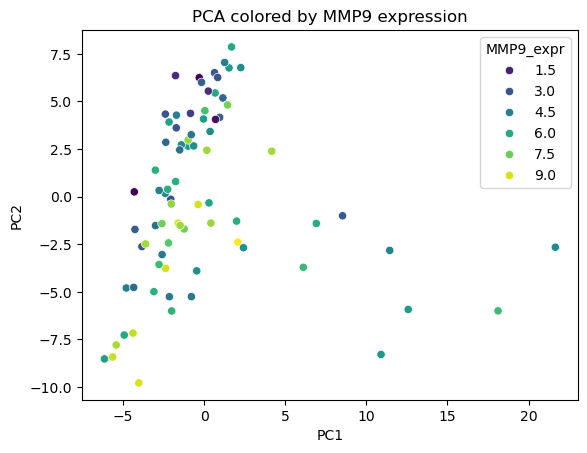

In [7]:
# Importing the libraries we need for this analysis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# Load in the gene expression data and the metadata
# index_col=0 means the first column is used as row the labels
data = pd.read_csv(
    '/Users/haydenrue/Desktop/Comp BME/Module-4-Cancer/data/TRAINING_SET_GSE62944_subsample_log2TPM.csv',
    index_col=0
)

metadata_df = pd.read_csv(
    '/Users/haydenrue/Desktop/Comp BME/Module-4-Cancer/data/TRAINING_SET_GSE62944_metadata.csv',
    index_col=0
)

# Print shapes to confirm everything loaded correctly
print("Data shape:", data.shape)
print("Metadata shape:", metadata_df.shape)


# The sample IDs in the gene data and metadata don’t perfectly match,
# so we shorten them to the first 12 characters
data_short = data.columns.str[:12]
meta_short = metadata_df.index.str[:12]

# map shortened IDs back to full IDs
data_map = dict(zip(data_short, data.columns))
meta_map = dict(zip(meta_short, metadata_df.index))

# Find which patient IDs exist in both datasets
common_ids = set(data_short).intersection(set(meta_short))
print("Matched patients:", len(common_ids))

# Use only the matched samples
data_cols_final = [data_map[i] for i in common_ids]
meta_idx_final = [meta_map[i] for i in common_ids]

data = data[data_cols_final]
metadata_df = metadata_df.loc[meta_idx_final]


# Filter down to only SKCM (melanoma) samples
cancer_type = 'SKCM'

cancer_samples = metadata_df[metadata_df['cancer_type'] == cancer_type].index
common_samples = data.columns.intersection(cancer_samples)

print("Matched SKCM samples:", len(common_samples))

SKCM_data = data[common_samples]
SKCM_metadata = metadata_df.loc[common_samples]


# Select the most variable genes since they carry the most information
# Also make sure MMP9 is included even if it’s not the most variable
gene_variance = SKCM_data.var(axis=1)
top_genes = gene_variance.sort_values(ascending=False).head(150).index

genes = list(set(top_genes).union({'MMP9'}))
SKCM_gene_data = SKCM_data.loc[genes]

print("Gene data shape:", SKCM_gene_data.shape)


# Combine gene expression data with clinical metadata into one dataframe
# Transpose is needed so samples become rows
SKCM_merged = SKCM_gene_data.T.merge(
    SKCM_metadata, left_index=True, right_index=True
)


# Remove rows with missing values for key variables we need
SKCM_merged = SKCM_merged.dropna(subset=[
    'MMP9',
    'ajcc_nodes_pathologic_pn',
    'ajcc_metastasis_pathologic_pm',
    'ajcc_pathologic_tumor_stage',
    'OS',
    'OS.time'
])


# PCA (Principal Component Analysis)
# This reduces the dataset into 2 dimensions to visualize patterns

X = SKCM_gene_data.T

# Standardize the data so all genes are on the same scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Run PCA and keep the first 2 components
pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

# Store PCA results in a dataframe
pca_df = pd.DataFrame(pcs, columns=['PC1', 'PC2'], index=X.index)
pca_df = pca_df.merge(SKCM_metadata, left_index=True, right_index=True)

# Show how much variance in each component
print("Explained variance:", pca.explained_variance_ratio_)

# Color PCA plot by MMP9 expression level
pca_df['MMP9_expr'] = SKCM_gene_data.loc['MMP9']

sns.scatterplot(data=pca_df, x='PC1', y='PC2',
                hue='MMP9_expr', palette='viridis')
plt.title("PCA colored by MMP9 expression")
plt.show()


K-Means clustering was then implemented to analyze subgroups of patients based on gene expression similarity. The plot is colored by the different clusters.

Data shape: (15716, 1802)
Metadata shape: (1802, 29)
Matched patients: 1795
Matched SKCM samples: 80
Gene data shape: (151, 80)


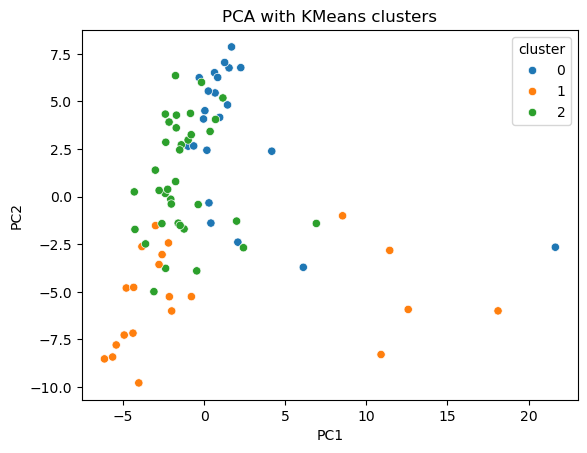

cluster
0    5.545786
1    5.708670
2    5.240920
Name: MMP9_expr, dtype: float64
MMP9_high
False    0.435897
True     0.435897
Name: OS, dtype: float64


In [9]:
# Importing the libraries we need for this analysis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# Load in the gene expression data and the metadata
# index_col=0 means the first column is used as row the labels
data = pd.read_csv(
    '/Users/haydenrue/Desktop/Comp BME/Module-4-Cancer/data/TRAINING_SET_GSE62944_subsample_log2TPM.csv',
    index_col=0
)

metadata_df = pd.read_csv(
    '/Users/haydenrue/Desktop/Comp BME/Module-4-Cancer/data/TRAINING_SET_GSE62944_metadata.csv',
    index_col=0
)

# Print shapes to confirm everything loaded correctly
print("Data shape:", data.shape)
print("Metadata shape:", metadata_df.shape)


# The sample IDs in the gene data and metadata don’t perfectly match,
# so we shorten them to the first 12 characters
data_short = data.columns.str[:12]
meta_short = metadata_df.index.str[:12]

# map shortened IDs back to full IDs
data_map = dict(zip(data_short, data.columns))
meta_map = dict(zip(meta_short, metadata_df.index))

# Find which patient IDs exist in both datasets
common_ids = set(data_short).intersection(set(meta_short))
print("Matched patients:", len(common_ids))

# Use only the matched samples
data_cols_final = [data_map[i] for i in common_ids]
meta_idx_final = [meta_map[i] for i in common_ids]

data = data[data_cols_final]
metadata_df = metadata_df.loc[meta_idx_final]


# Filter down to only SKCM (melanoma) samples
cancer_type = 'SKCM'

cancer_samples = metadata_df[metadata_df['cancer_type'] == cancer_type].index
common_samples = data.columns.intersection(cancer_samples)

print("Matched SKCM samples:", len(common_samples))

SKCM_data = data[common_samples]
SKCM_metadata = metadata_df.loc[common_samples]


# Select the most variable genes since they carry the most information
# Also make sure MMP9 is included even if it’s not the most variable
gene_variance = SKCM_data.var(axis=1)
top_genes = gene_variance.sort_values(ascending=False).head(150).index

genes = list(set(top_genes).union({'MMP9'}))
SKCM_gene_data = SKCM_data.loc[genes]

print("Gene data shape:", SKCM_gene_data.shape)


# Combine gene expression data with clinical metadata into one dataframe
# Transpose is needed so samples become rows
SKCM_merged = SKCM_gene_data.T.merge(
    SKCM_metadata, left_index=True, right_index=True
)


# Remove rows with missing values for key variables we need
SKCM_merged = SKCM_merged.dropna(subset=[
    'MMP9',
    'ajcc_nodes_pathologic_pn',
    'ajcc_metastasis_pathologic_pm',
    'ajcc_pathologic_tumor_stage',
    'OS',
    'OS.time'
])

# Clustering using K-Means

kmeans = KMeans(n_clusters=3, random_state=42)
pca_df['cluster'] = kmeans.fit_predict(X_scaled)

# Plot PCA with cluster labels
sns.scatterplot(data=pca_df, x='PC1', y='PC2',
                hue='cluster', palette='tab10')
plt.title("PCA with KMeans clusters")
plt.show()

# Compare average MMP9 expression across clusters
pca_df['MMP9_expr'] = SKCM_gene_data.loc['MMP9']
print(pca_df.groupby('cluster')['MMP9_expr'].mean())

# Compare survival status between high and low MMP9 groups
SKCM_merged['MMP9_high'] = SKCM_merged['MMP9'] > SKCM_merged['MMP9'].median()
print(SKCM_merged.groupby('MMP9_high')['OS'].mean())

## Verify and validate your analysis: 
*Pick a SPECIFIC metric to determine how well your model is performing and describe how it works here.*

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## AI Usage Statement: 
AI was used to ensure our question could be analyed adequately from our data.

## QUESTIONS FOR YOUR TA: 
*These are questions we have for our TA.*